In [1]:
import os
# set cwd to the test directory
os.chdir("/home/dev/physioex")

In [2]:

import sys
from pathlib import Path
root = Path( "/home/dev/physioex/test" )

sys.path.insert(0, str(root ))

sys.path.insert(0, str(root / "data" ))
sys.path.insert(0, str(root / "models" ))
sys.path.insert(0, str(root / "train" ))
sys.path.insert(0, str(root / "explain" ))

print( sys.path )

['/home/dev/physioex/test/explain', '/home/dev/physioex/test/train', '/home/dev/physioex/test/models', '/home/dev/physioex/test/data', '/home/dev/physioex/test', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/dev/.venv/torch/lib/python3.12/site-packages']


In [3]:
# set cwd to the test directory
import torch
import os 

from data.dataset import get_dataloaders, PhysioExDataset
from models.protosleepnet import ProtoSleepNet, ProtoSleepNetTrainer
import torch

    
dataset = PhysioExDataset(
    datasets = [ "mass" ]
)
_, loader, _ = get_dataloaders( dataset )

path = [ p for p in os.listdir( "checkpoints/train_0/") if p.startswith("epoch=") and p.endswith(".pt") ][0]

model = ProtoSleepNet(
    in_chan = dataset.get_num_channels(),
    cdropout = 1.0,
    cmnlayers = 4,
)
model, _, _= ProtoSleepNetTrainer.load_checkpoint( model, path=os.path.join( "checkpoints/train_0/", path ) )
model = model.eval()


[Info - PhysioExDataset]: Loaded configuration from PHYSIOEX_CONFIG.yaml file.


In [4]:
from explain.prototypes.local import get_prototypes, PrototypeRelevance, proj_fn
from explain.prototypes.reconstruct import data_driven_reconstruction, model_driven_reconstructions

stages = [ "W", "N1", "N2", "N3", "R" ]
prototypes = get_prototypes( model )

with torch.no_grad():
    proto_preds = model.clf( prototypes ).cpu()
    proto_preds = torch.nn.functional.softmax( proto_preds, dim=-1 )

# for each prototype print the stages with confidence higher than 0.2 on one line
for i, proto_pred in enumerate( proto_preds ):
    labels = [ f"{stage}: {conf:.3f}" for stage, conf in zip( stages, proto_pred ) if conf > 0.2 ]
    print( f"Prototype {i}: " + ", ".join( labels ) )

Prototype 0: W: 0.461, N1: 0.337
Prototype 1: N2: 0.418, R: 0.430
Prototype 2: W: 0.273, R: 0.210
Prototype 3: N2: 0.618, N3: 0.362
Prototype 4: W: 0.968
Prototype 5: R: 0.926
Prototype 6: N2: 0.970
Prototype 7: N1: 0.251, N2: 0.492, R: 0.205
Prototype 8: N2: 0.604
Prototype 9: N2: 0.235, R: 0.286
Prototype 10: N2: 0.319, N3: 0.244, R: 0.231
Prototype 11: N2: 0.211, N3: 0.365
Prototype 12: N2: 0.272, N3: 0.234, R: 0.203
Prototype 13: W: 0.244, N1: 0.270, R: 0.325
Prototype 14: N3: 0.973


In [20]:
index = 14
n = 1
device = torch.device("cuda:1")

def min_fidelity_instance(
    loader: torch.utils.data.DataLoader,
    model: ProtoSleepNet,
    index: int = 0,
    device: torch.device = torch.device("cpu"),
):
    model.eval()
    model.to(device)
    prototypes = get_prototypes(model).to(device)
    prototype = prototypes[index].unsqueeze(0)

    min_val = float("inf")
    min_x = None

    for batch in loader:
        x, y = batch

        # x shape: batch x L x in_chans x T x F
        # y shape: batch x L
        batch_size, L, in_chans, T, F = x.shape
        y = y.reshape(batch_size * L)
        x = x.reshape(batch_size * L, in_chans, T, F)

        mask = y != -1
        if not torch.any(mask):
            continue

        x = x[mask].to(device).float()

        with torch.no_grad():
            embeddings = proj_fn(model, x)
            all_sim = torch.nn.functional.cosine_similarity(
                embeddings.unsqueeze(1),
                prototypes.unsqueeze(0),
                dim=-1,
            )
            assigned_mask = all_sim.argmax(dim=1) == int(index)
            if not torch.any(assigned_mask):
                continue

            filtered_x = x[assigned_mask]
            sims = torch.nn.functional.cosine_similarity(
                embeddings[assigned_mask],
                prototype,
            )
            batch_min_val, batch_min_idx = torch.min(sims, dim=0)
            if float(batch_min_val.item()) < min_val:
                min_val = float(batch_min_val.item())
                min_x = filtered_x[batch_min_idx].detach().cpu()

    return min_x

min_instance = min_fidelity_instance(
    loader,
    model,
    index=index,
    device=device,
)

if min_instance is None:
    raise RuntimeError("No instance assigned to the target prototype.")

min_instance = min_instance.unsqueeze(0) if n == 1 else min_instance

print("Min-fidelity similarity to prototype:")
with torch.no_grad():
    min_proj = proj_fn(model.to(device), min_instance.to(device)).cpu()
    prototype = get_prototypes(model, index=index)
    min_sim = torch.nn.functional.cosine_similarity(
        min_proj,
        prototype.unsqueeze(0),
        dim=-1,
    )
print(min_sim.mean())

optimized = model_driven_reconstructions(
    model,
    index=index,
    device=device,
    n=1,
    init=min_instance,
    steps=1000,
    lr=1e-3,
)


print("Optimized similarity to prototype:")
with torch.no_grad():
    opt_proj = proj_fn(model.to(device), optimized.to(device)).cpu()
    opt_sim = torch.nn.functional.cosine_similarity(
        opt_proj,
        prototype.unsqueeze(0),
        dim=-1,
    )
print(opt_sim.mean())

Min-fidelity similarity to prototype:
tensor(0.4512)


Optimized similarity to prototype:
tensor(0.9892)


In [14]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-darkgrid")

import numpy as np


In [15]:
CHANNELS = ["EEG", "EOG", "EMG"]
fs = 100
freqs = np.arange(0, 129) * fs / 2 / 128

In [16]:
# (optional) time axis if needed later
times = np.arange(0, 29)

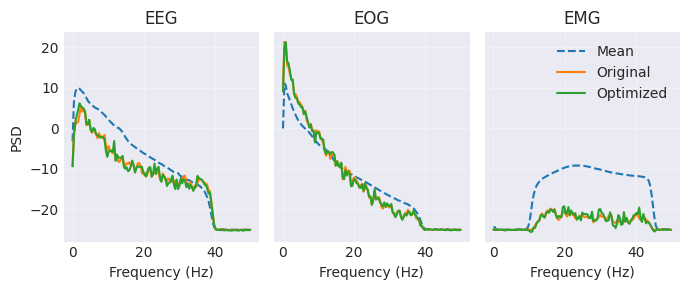

In [21]:
mean, std = dataset.get_scaling()

def _psd_mean_over_time(x):
    # Accept shapes: (n, C, T, F) or (C, T, F)
    if x is None:
        return None
    if x.dim() == 3:
        x = x.unsqueeze(0)
    x = x.detach().cpu()

    x = x * std + mean

    psd = x.mean(dim=0).mean(dim=1)  # (C, F), mean over n and T
    return psd

mean_instance = torch.zeros_like(min_instance)
psd_orig = _psd_mean_over_time(min_instance)
psd_opt = _psd_mean_over_time(optimized)
psd_mean = _psd_mean_over_time(mean_instance)

num_chans = min(3, psd_orig.shape[0], psd_opt.shape[0], psd_mean.shape[0])

fig, axes = plt.subplots(1, num_chans, figsize=(7, 3), sharex=True, sharey=True)
if num_chans == 1:
    axes = np.array([axes])

for ch in range(num_chans):
    axes[ch].plot(freqs, psd_mean[ch].numpy(), label="Mean", linestyle="--")
    axes[ch].plot(freqs, psd_orig[ch].numpy(), label="Original")
    axes[ch].plot(freqs, psd_opt[ch].numpy(), label="Optimized")
    axes[ch].set_title(f"{CHANNELS[ch]}")
    axes[ch].grid(True, alpha=0.3)
    axes[ch].set_xlabel("Frequency (Hz)")

axes[0].set_ylabel("PSD")
axes[-1].legend()

plt.tight_layout()
plt.savefig("prototype15_min_fidelity_optimization.pdf", bbox_inches="tight")